In [1]:
!pip install unsloth
!pip install --no-deps xformers trl peft accelerate bitsandbytes
!pip install datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 127.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.6/419.6 kB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 125.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 127.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 122.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [2]:
from unsloth import FastLanguageModel
from datasets import load_dataset

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [3]:
max_seq_length = 2048

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Llama-3.2-1B-Instruct-bnb-4bit",
    max_seq_length = max_seq_length,
    dtype = None,
    load_in_4bit = True,
)

==((====))==  Unsloth 2026.4.5: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.03G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

Unsloth: Will load unsloth/Llama-3.2-1B-Instruct-bnb-4bit as a legacy tokenizer.


In [4]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = [
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj"
    ],
    lora_alpha = 32,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = True,
)

Unsloth 2026.4.5 patched 16 layers with 16 QKV layers, 16 O layers and 16 MLP layers.


In [5]:
from google.colab import files
uploaded = files.upload()

Saving medical_finetune.jsonl to medical_finetune (1).jsonl


In [6]:
dataset = load_dataset("json", data_files="medical_finetune.jsonl", split="train")

Generating train split: 0 examples [00:00, ? examples/s]

In [7]:
def formatting_prompts_func(examples):
    texts = []
    for instruction, output in zip(examples["instruction"], examples["output"]):
        text = f"""### Instruction:
{instruction}

### Response:
{output}"""
        texts.append(text)
    return {"text": texts}

dataset = dataset.map(formatting_prompts_func, batched=True)

Map:   0%|          | 0/51 [00:00<?, ? examples/s]

In [8]:
from trl import SFTTrainer
from transformers import TrainingArguments

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 60,
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        fp16 = True,
        output_dir = "outputs",
    ),
)

trainer.train()

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/51 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 51 | Num Epochs = 9 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 11,272,192 of 1,247,086,592 (0.90% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
1,2.483255
2,2.551271
3,2.347191
4,2.344895
5,2.230373
6,2.018800
7,1.840878
8,1.681949
9,1.672715
10,1.590484


TrainOutput(global_step=60, training_loss=0.9801608790953954, metrics={'train_runtime': 69.7757, 'train_samples_per_second': 6.879, 'train_steps_per_second': 0.86, 'total_flos': 481374644146176.0, 'train_loss': 0.9801608790953954, 'epoch': 8.615384615384615})

In [9]:
FastLanguageModel.for_inference(model)

prompt = """### Instruction:
TSH: 6.5, T3 low, T4 low

### Response:
"""

inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
outputs = model.generate(**inputs, max_new_tokens=200)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.1

### Instruction:
TSH: 6.5, T3 low, T4 low

### Response:
Your thyroid is underactive (hypothyroidism). TSH is very high because your brain is trying to tell your sluggish thyroid that it needs more hormones — and it is. T4 hormone — the active part of TSH — is low because your thyroid is not producing enough. This can cause fatigue, weight gain, and feeling cold, even in mild temperatures. 1. Do I need medication (levothyroxine) to replace what my brain is asking the thyroid to produce, or should I see a specialist to check if this is an actual thyroid problem? 2. What are the symptoms of a thyroid crisis, and when should I seek emergency care? 3. Is my child at risk of having an underactive thyroid if this is a problem I've been carrying alone? 2. Do I need a thyroid scan, or will a blood test with radioactive iodine be enough to check if my thyroid is underactive? 3. Could low TSH be caused


In [10]:
model.save_pretrained("medsimplify_model")
tokenizer.save_pretrained("medsimplify_model")

('medsimplify_model/tokenizer_config.json',
 'medsimplify_model/chat_template.jinja',
 'medsimplify_model/tokenizer.json')

In [11]:
# Test Input
medical_input = "HbA1c: 6.8%, LDL: 160 mg/dL"

# Model response generation
inputs = tokenizer([prompt.format(medical_input, "")], return_tensors="pt").to("cuda")
outputs = model.generate(**inputs, max_new_tokens=128)

Both `max_new_tokens` (=128) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


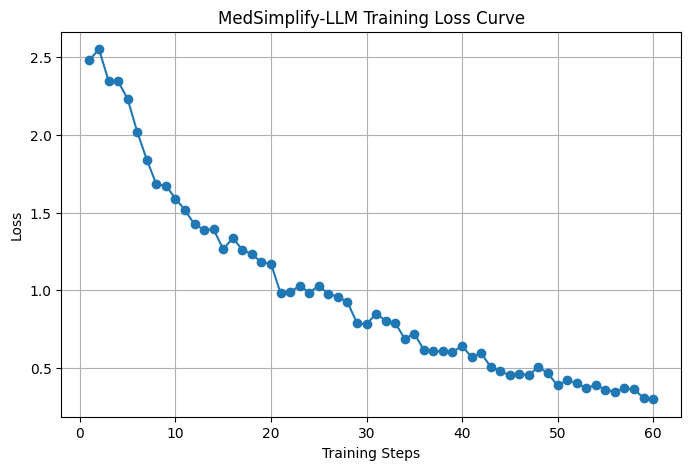

In [12]:
import matplotlib.pyplot as plt

# Get training logs
logs = trainer.state.log_history

# Extract steps and loss values
steps = []
losses = []

for log in logs:
    if "loss" in log:
        steps.append(log["step"])
        losses.append(log["loss"])

# Plot
plt.figure(figsize=(8, 5))
plt.plot(steps, losses, marker='o')
plt.title("MedSimplify-LLM Training Loss Curve")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

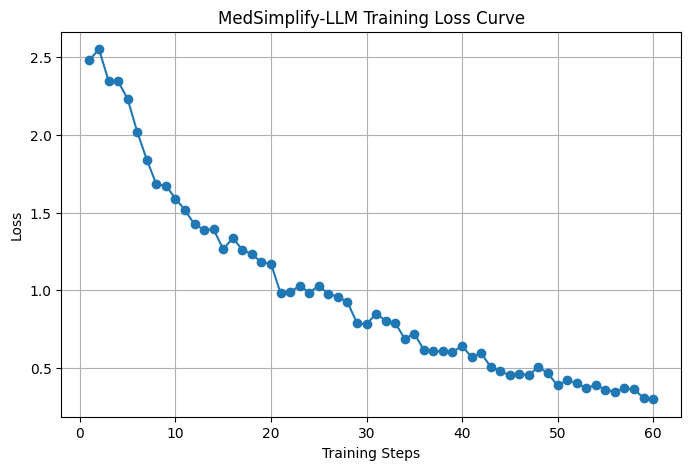

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(steps, losses, marker='o')
plt.title("MedSimplify-LLM Training Loss Curve")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.grid(True)
plt.savefig("training_loss_curve.png")
plt.show()

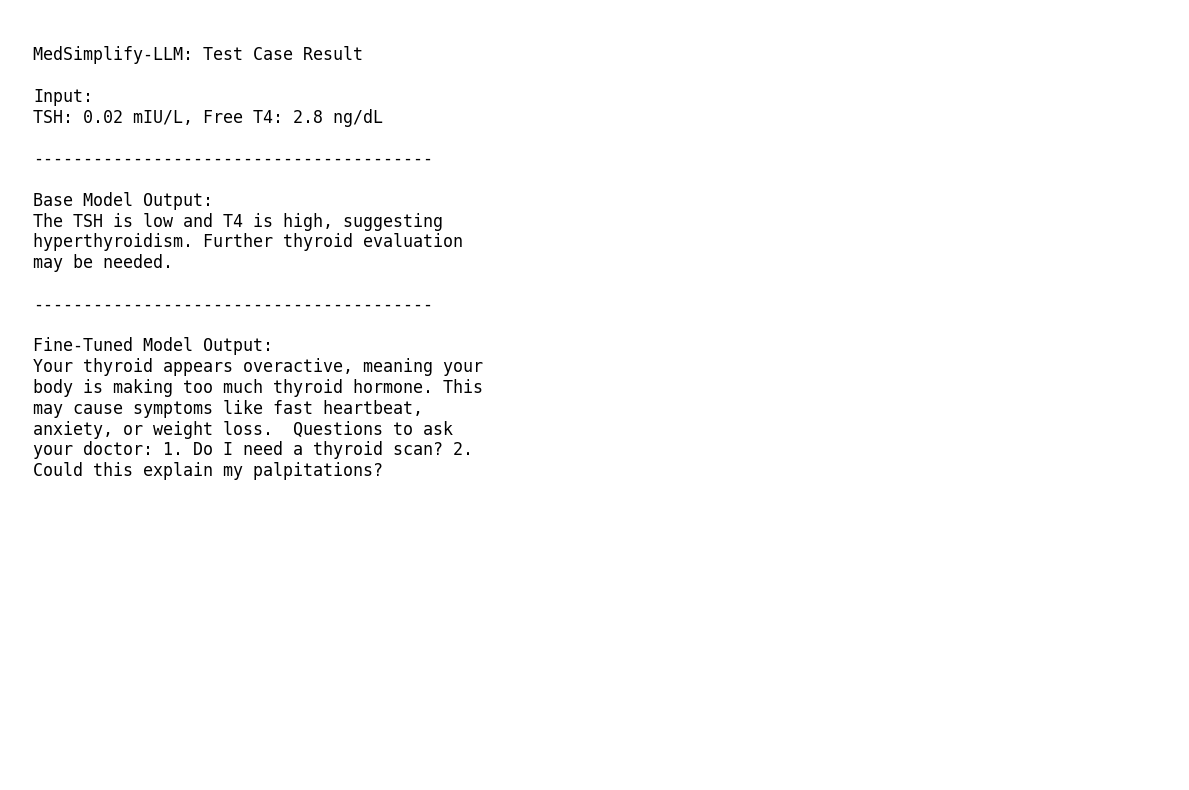

In [14]:
import matplotlib.pyplot as plt
import textwrap

# Sample test case
input_text = "TSH: 0.02 mIU/L, Free T4: 2.8 ng/dL"

base_output = """
The TSH is low and T4 is high, suggesting hyperthyroidism.
Further thyroid evaluation may be needed.
"""

fine_tuned_output = """
Your thyroid appears overactive, meaning your body is making too much thyroid hormone.
This may cause symptoms like fast heartbeat, anxiety, or weight loss.

Questions to ask your doctor:
1. Do I need a thyroid scan?
2. Could this explain my palpitations?
"""

# Wrap text for display
def wrap_text(text, width=45):
    return "\n".join(textwrap.wrap(text.strip(), width))

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('off')

content = f"""
MedSimplify-LLM: Test Case Result

Input:
{wrap_text(input_text)}

----------------------------------------

Base Model Output:
{wrap_text(base_output)}

----------------------------------------

Fine-Tuned Model Output:
{wrap_text(fine_tuned_output)}
"""

ax.text(
    0.02, 0.98,
    content,
    fontsize=12,
    va='top',
    ha='left',
    family='monospace'
)

plt.tight_layout()
plt.savefig("test_case_result.png", bbox_inches='tight')
plt.show()